# 🎓 Student Performance Analysis
### Tools: Python | Pandas | Matplotlib
### Dataset: 1000 students with scores in Math, Reading & Writing

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Import Libraries & Load Data
Loading the dataset and previewing its structure.

In [5]:
df = pd.read_csv("StudentsPerformance.csv")

In [6]:
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None


In [8]:
print(df.shape)

(1000, 8)


In [9]:
print(df.describe())

       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


In [10]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


## 2. Feature Engineering
Creating new columns: Total Marks, Percentage, and Pass/Fail Result.

In [11]:
df["total_marks"] = df["math score"] + df["reading score"] + df["writing score"]

In [12]:
df["percentage"] = df["total_marks"]/3

In [13]:
df["result"] = df["percentage"].apply(lambda x : "Pass" if x >= 40 else "Fail") 

In [14]:
print(df["percentage"].mean())

67.77066666666666


In [15]:
top_student=df.loc[df["total_marks"].idxmax()]
print(top_student)

gender                                    female
race/ethnicity                           group E
parental level of education    bachelor's degree
lunch                                   standard
test preparation course                     none
math score                                   100
reading score                                100
writing score                                100
total_marks                                  300
percentage                                 100.0
result                                      Pass
Name: 458, dtype: object


In [16]:
print(df["result"].value_counts())

result
Pass    970
Fail     30
Name: count, dtype: int64


## 3. Key Insights
Analyzing performance by Gender, Parental Education, and Test Preparation.

In [17]:
print(df.groupby ("gender")["percentage"].mean())

gender
female    69.569498
male      65.837483
Name: percentage, dtype: float64


In [18]:
print(df.groupby("test preparation course")["percentage"].mean())
#Students completing test preparation scored higher.

test preparation course
completed    72.669460
none         65.038941
Name: percentage, dtype: float64


In [19]:
print(df.groupby("race/ethnicity")["percentage"].mean())
# Group E has the highest average

race/ethnicity
group A    62.992509
group B    65.468421
group C    67.131661
group D    69.179389
group E    72.752381
Name: percentage, dtype: float64


In [20]:
print(df[["math score","reading score","writing score"]].mean())


math score       66.089
reading score    69.169
writing score    68.054
dtype: float64


In [21]:
print(df.groupby("parental level of education")["percentage"].mean())
# Master's degree is better on average

parental level of education
associate's degree    69.569069
bachelor's degree     71.923729
high school           63.096939
master's degree       73.598870
some college          68.476401
some high school      65.108007
Name: percentage, dtype: float64


In [22]:
top_10 = df.sort_values("percentage", ascending=False).head(10)
print(top_10)

     gender race/ethnicity parental level of education         lunch  \
916    male        group E           bachelor's degree      standard   
458  female        group E           bachelor's degree      standard   
962  female        group E          associate's degree      standard   
114  female        group E           bachelor's degree      standard   
179  female        group D            some high school      standard   
712  female        group D                some college      standard   
165  female        group C           bachelor's degree      standard   
625    male        group D                some college      standard   
903  female        group D           bachelor's degree  free/reduced   
149    male        group E          associate's degree  free/reduced   

    test preparation course  math score  reading score  writing score  \
916               completed         100            100            100   
458                    none         100            100       

## 4. Data Visualization
Visual representation of score distributions and group comparisons.

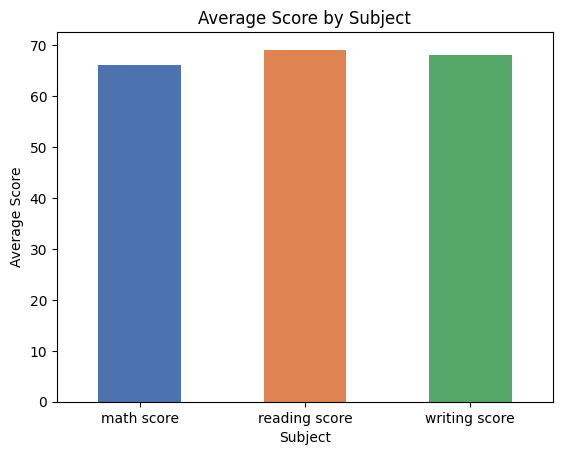

In [23]:
df[["math score", "reading score","writing score"]].mean().plot(
    kind="bar",
    xlabel="Subject",
    ylabel="Average Score",
    color=["#4C72B0", "#DD8452", "#55A868"],
    title="Average Score by Subject"
)
plt.xticks(rotation=0)
plt.show()

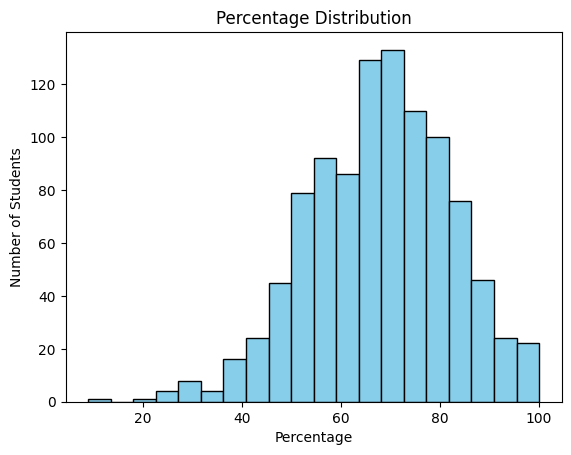

In [24]:
df["percentage"].plot(kind="hist", bins=20,color="skyblue", edgecolor="black")
plt.title("Percentage Distribution")
plt.xlabel("Percentage")
plt.ylabel("Number of Students")
plt.show()

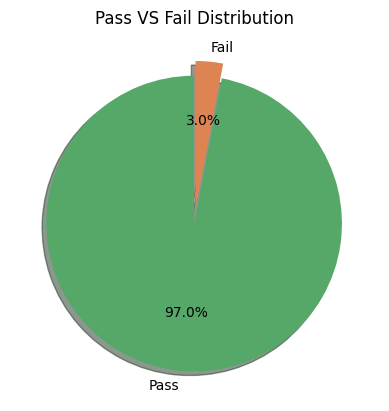

In [25]:
df["result"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    title="Pass VS Fail Distribution",
    ylabel="",
    colors=["#55A868", "#DD8452"],
    explode=[0.05, 0.05],
    shadow=True,
    startangle=90
)
plt.show()

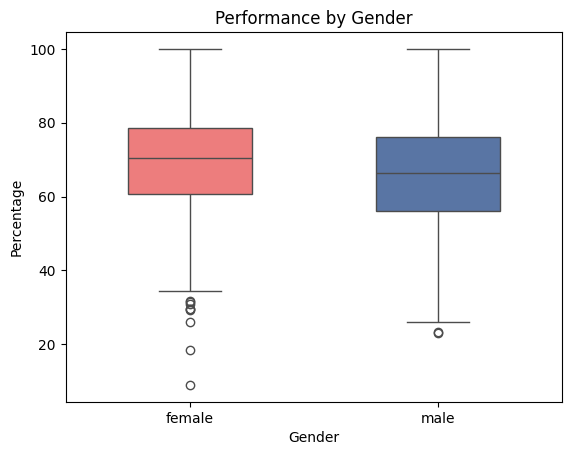

In [26]:
sns.boxplot(
    data=df,
    x="gender",
    y="percentage",
    hue="gender",
    palette={"female": "#FF6B6B", "male": "#4C72B0"},
    width=0.5,
    legend=False
)
plt.title("Performance by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.suptitle("")
plt.show()

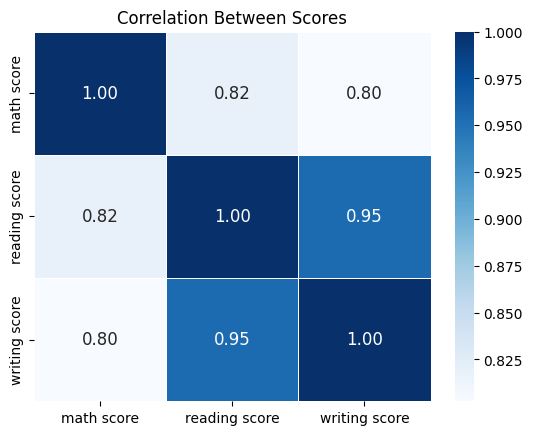

In [27]:
sns.heatmap(
    df[["math score","reading score","writing score"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 12}
)
plt.title("Correlation Between Scores")
plt.show()

## 5. Conclusion
- ✅ **97%+ students passed** the exam
- 📚 Students who completed **test preparation scored higher**
- 👩 **Female students** performed better overall than male students
- 🎓 Students with parents having **Master's degree** had highest average scores
- 📊 Reading and Writing scores are **strongly correlated**